In [49]:
import wandb
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tikzplotlib import save as tikz_save
from concurrent.futures import ThreadPoolExecutor, as_completed
import math
import re


GOLD = "#FFB000"
PURPLE = "#785EF0"
ORANGE = "#FE6100"
BLU = "#648FFF"
PINK = "#DC267F"
BLACK = "black"

In [50]:
api = wandb.Api()
runs = list(api.runs(
    "alessandro-montenegro-polimi/forzaroma-rt-ppo-reacher",
    filters={
        "tags": {"$in": ["baseline", "wppo_1"]}, 
        "state": "finished",
        "config.experiment.on_policy_critic": True
        },
    per_page=100
))


In [51]:
# GET ALL RUNS IN PARALLEL

# --- Define your metrics here ---
METRICS = [
    "diagnostics_clip/pre_w0",
    "diagnostics_clip/pre_w1",
    "diagnostics_clip/pre_w2",
    "diagnostics_clip/pre_w3",
    "diagnostics_clip/pre_w4",
    "diagnostics_clip/pre_w5",
    "diagnostics_clip/pre_w6",
    "diagnostics_clip/pre_w7",
    
    "diagnostics_clip/post_w0",
    "diagnostics_clip/post_w1",
    "diagnostics_clip/post_w2",
    "diagnostics_clip/post_w3",
    "diagnostics_clip/post_w4",
    "diagnostics_clip/post_w5",
    "diagnostics_clip/post_w6",
    "diagnostics_clip/post_w7",
]

def fetch_run(run, metrics):
    hists = []

    for metric in metrics:
        hist = run.history(keys=["global_step", metric], samples=500, pandas=True)
        if not hist.empty and "global_step" in hist.columns:
            hist = hist.drop(columns=["_step"], errors="ignore")  # drop W&B internal col
            hists.append(hist.sort_values("global_step"))

    if not hists:
        return None

    merged = hists[0]
    for hist in hists[1:]:
        merged = pd.merge_asof(merged, hist, on="global_step", direction="nearest")

    merged["on_policy_critic"]  = run.config["experiment"]["on_policy_critic"]
    merged["seed"]  = run.config["experiment"]["seed"]
    merged["group"] = run.config["group_name"]
    merged["tag"]   = next((t for t in run.tags if t in {"baseline", "wppo_1", "wppo_3", "wppo_3_v2"}), "unknown")

    if run.config["experiment"]["window_size"] > 1:
        merged["weight_type"]  = run.config["experiment"]["weight_type"]
        merged["window_size"]  = run.config["experiment"]["window_size"]
    else:
        merged["weight_type"]  = "none"
        merged["window_size"]  = 1

    return merged

with ThreadPoolExecutor(max_workers=8) as executor:
    records = list(executor.map(lambda run: fetch_run(run, METRICS), runs))

records = [r for r in records if r is not None]
df = pd.concat(records, ignore_index=True)

In [52]:
# Substitute bh values into naive where weight_type is bh

naive_cols = [c for c in df.columns if "naive" in c]
bh_cols    = [c for c in df.columns if "bh"    in c]

pairs = [(n, n.replace("naive", "bh")) for n in naive_cols if n.replace("naive", "bh") in bh_cols]

print("Column pairs found:")
for n, b in pairs:
    print(f"  {n}  <-->  {b}")

df = df.copy()

mask_bh    = df["weight_type"] == "bh"

for naive_col, bh_col in pairs:
    df.loc[mask_bh,    naive_col] = df.loc[mask_bh,    bh_col].values

print(f"Updated {mask_bh.sum()} bh rows")

Column pairs found:
Updated 8520 bh rows


In [53]:
# %%
# Replace inf/-inf with NaN, then they will be ignored by .mean()
import numpy as np

for metric in METRICS:
    if metric in df.columns:
        df[metric] = pd.to_numeric(df[metric], errors="coerce")          # strings → NaN
        df[metric] = df[metric].replace([np.inf, -np.inf], np.nan)       # inf → NaN

In [54]:
from collections import defaultdict

METRIC_GROUPS = {
    "diagnostics_clip/pre":  [
        "diagnostics_clip/pre_w0",  
        "diagnostics_clip/pre_w1",  
        "diagnostics_clip/pre_w2",  
        "diagnostics_clip/pre_w3",  
        "diagnostics_clip/pre_w4",  
        "diagnostics_clip/pre_w5",  
        "diagnostics_clip/pre_w6",  
        "diagnostics_clip/pre_w7"
        ],

    "diagnostics_clip/post": [
        "diagnostics_clip/post_w0", 
        "diagnostics_clip/post_w1", 
        "diagnostics_clip/post_w2", 
        "diagnostics_clip/post_w3", 
        "diagnostics_clip/post_w4", 
        "diagnostics_clip/post_w5", 
        "diagnostics_clip/post_w6", 
        "diagnostics_clip/post_w7"
        ],
}

metrics_store = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))

for w in sorted(df["window_size"].unique()):
    df_w = df[df["window_size"] == w]

    for wt in df_w["weight_type"].unique():
        df_wt = df_w[df_w["weight_type"] == wt]

        for group, metrics in METRIC_GROUPS.items():
            means, stds = [], []

            for metric in metrics:
                per_seed = df_wt.groupby("seed")[metric].mean()
                means.append(per_seed.mean())
                stds.append(per_seed.std())

            metrics_store[w][wt][group] = {
                "indices": list(range(len(metrics))),  # [0, 1, 2, ..., 7]
                "means":   means,
                "stds":    stds,
            }

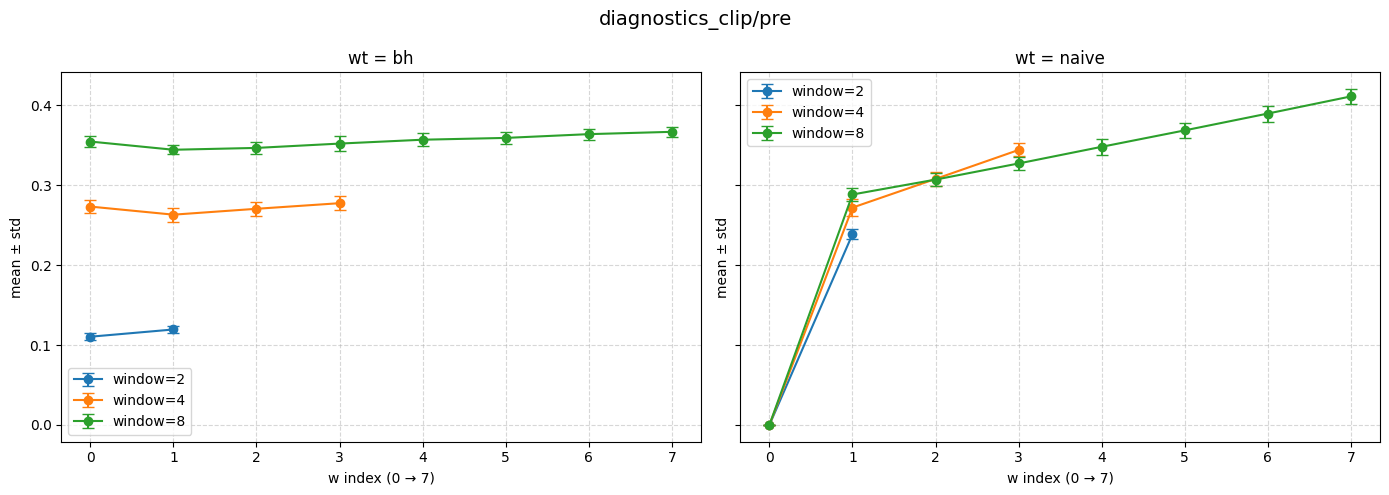

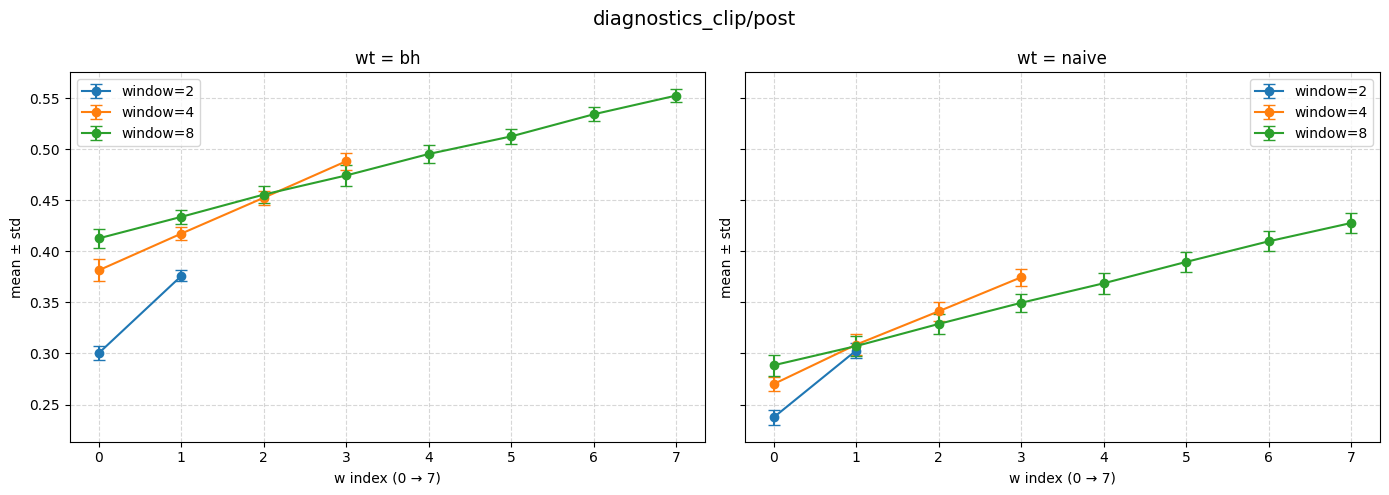

In [55]:
import matplotlib.pyplot as plt

WEIGHT_TYPES = ["bh", "naive"]
WINDOW_SIZES = sorted(df["window_size"].unique())

for group in METRIC_GROUPS:
    fig, axes = plt.subplots(1, len(WEIGHT_TYPES), figsize=(14, 5), sharey=True)
    fig.suptitle(group, fontsize=14)

    for ax, wt in zip(axes, WEIGHT_TYPES):
        for w in WINDOW_SIZES:
            data = metrics_store[w][wt][group]
            if data == {}:
                continue

            indices = data["indices"]
            means   = data["means"]
            stds    = data["stds"]

            ax.errorbar(indices, means, yerr=stds,
                        marker="o", capsize=4, label=f"window={w}")

        ax.set_title(f"wt = {wt}")
        ax.set_xlabel("w index (0 → 7)")
        ax.set_ylabel("mean ± std")
        ax.set_xticks(indices)
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()